In [9]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [10]:
f = h5py.File("data/h2_results.hdf5", "r")
tebd_all_h = f["tebd_all_h"][:, :]
tebd_all_s = f["tebd_all_s"][:, :]
h_u = f["h_u"][:, :]
s_u = f["s_u"][:, :]
tebd_energies = f["tebd_energies"][:]
energies_u = f["energies_u"][:]
num_kept = f["num_kept"][:]
num_kept_u = f["num_kept_u"][:]
hf_energy = f["hf_energy"][()]
fci_energy = f["fci_energy"][()]
dmrg_energies = f["dmrg_energies"][()]
bond_sizes = f["bond_sizes"][()]
dmrg_bond_dims = f["dmrg_max_bond"][:]
tebd_bond_dims = f["tebd_max_bond"][:]
print(dmrg_bond_dims)
print(tebd_bond_dims)
f.close()

[1 2 5]
[1 2 5]


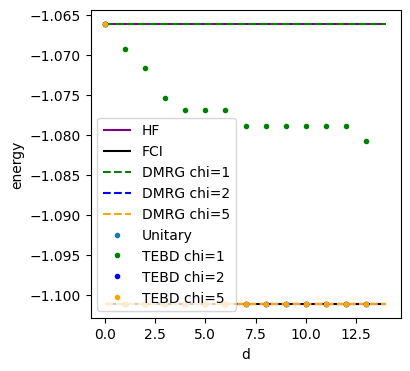

In [15]:
fig2, ax2 = plt.subplots(1, 1, figsize=(4, 4))
dmrg_colors = ["green", "blue", "orange"]
ax2.hlines(hf_energy, 0., tebd_energies.shape[1], colors=["purple"], label="HF")
ax2.hlines(fci_energy, 0., tebd_energies.shape[1], colors=["black"], label="FCI")
for i, (chi, dmrg_energy) in enumerate(zip(dmrg_bond_dims, dmrg_energies)):
    ax2.hlines(dmrg_energy, 0., tebd_energies.shape[1], linestyles=['--'], colors=[dmrg_colors[i]], label=f"DMRG chi={chi}")
ax2.plot(energies_u, '.', label="Unitary")
for i, chi in enumerate(tebd_bond_dims):
    ax2.plot(tebd_energies[i, :], '.', color=dmrg_colors[i], label=f"TEBD chi={chi}")
ax2.set_ylabel("energy")
ax2.set_xlabel("d")
ax2.legend(loc="lower left")

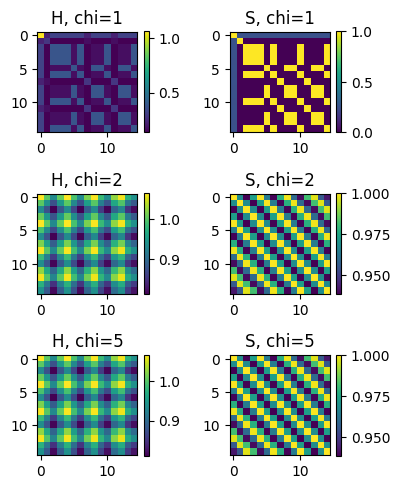

In [ ]:
fig3, ax3 = plt.subplots(len(tebd_bond_dims), 2, figsize=(4, 5))
for i, chi in enumerate(tebd_bond_dims):
    im1 = ax3[i, 0].imshow(np.abs(tebd_all_h[i, :, :]))
    ax3[i, 0].set_title(f"H, chi={chi}")
    im2 = ax3[i, 1].imshow(np.abs(tebd_all_s[i, :, :]))
    ax3[i, 1].set_title(f"S, chi={chi}")
    fig3.colorbar(im1)
    fig3.colorbar(im2)
fig3.tight_layout()